In [1]:
from transformers import AutoModelForImageClassification, AutoImageProcessor
from datasets import load_dataset
from PIL import Image

import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tqdm.notebook import trange, tqdm
from dotenv import load_dotenv
import os, json

from shared import visualize_model, plot_bar, set_neurips_style
from shared_masking import *

load_dotenv()
set_neurips_style()
cudnn.benchmark = True
plt.ion();

# 1. Using a Pre-trained ViT for Image Classification

In [2]:
MODEL = "facebook/deit-tiny-patch16-224"
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
SAMPLES_BASE="task-2-imagenet-samples"
BASE = "vit-task"
BASE_PLOTS = os.path.join(BASE, "plots")
MASK_RATIOS = [0.0, 0.25, 0.65, 0.95]

os.makedirs(BASE_PLOTS, exist_ok=True)
print(f"Using {DEVICE=}")

Using DEVICE='cuda'


In [ ]:
def load_model():
    processor = AutoImageProcessor.from_pretrained(MODEL)
    model = AutoModelForImageClassification.from_pretrained(MODEL, output_attentions=True, output_hidden_states=True).to(device=DEVICE)
    return processor, model

In [4]:
processor, model = load_model()
SHORT_CLASS_NAMES = {k:v.split(',')[0] for k,v in model.config.id2label.items()}

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [5]:
def read_from_disk(path):
    return Image.open(path)

def parse_label(path):
    return path.split("_")[-1].split(".")[0]

def read_samples():
    paths = os.listdir(SAMPLES_BASE)
    paths = [f"{SAMPLES_BASE}/{path}" for path in paths]
    samples = [(read_from_disk(path), parse_label(path).title()) for path in paths]
    return samples

def id_from_sample_label(sample_label):
    candidates = [label_id for label_id, label_name in model.config.id2label.items() if sample_label.lower() in label_name.lower()]
    assert len(candidates) == 1, f"Expected one label ID for {sample_label}, got {candidates}"
    return candidates[0]

def process_fn(inp):
    mean = np.array(processor.image_mean)
    std = np.array(processor.image_std)
    inp = std * inp + mean
    return inp

def forward(model, image):
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
    return inputs, outputs

def run_inference(model, image):
    inputs, outputs = forward(model, image)
    predicted_label = outputs.logits.argmax(-1).item()
    confidence = outputs.logits.softmax(-1).max(-1).values.item()
    return inputs.pixel_values[0], predicted_label, confidence

In [28]:
samples = read_samples()
samples = [(sample[0], id_from_sample_label(sample[1])) for sample in samples]

  0%|          | 0/3 [00:00<?, ?it/s]

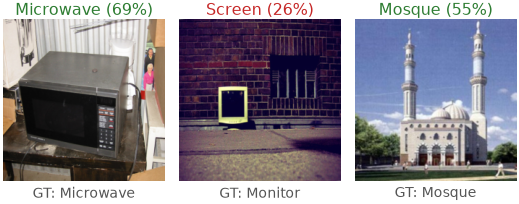

In [29]:
visualize_model(
    model,
    process_fn,
    samples,
    SHORT_CLASS_NAMES,
    run_inference,
    figsize=(3.5, 1.35),
    ncols=3,
)
plt.savefig(os.path.join(BASE_PLOTS, "model_visualization.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# 2. Visualizing Patch Attention and 3. Analyze the Attention Map

In [49]:
def extract_attention_mask_from_inputs(inputs):
    with torch.inference_mode():
        outputs = model(pixel_values=inputs)
        
    # this looks better than taking the average, the assignment allows selecting 1 head instead of taking the average
    cls_attentions = outputs.attentions[-1][:,0][:, 0, 1:]
    # cls_attentions = outputs.attentions[-1].mean(dim=1)[:, 0, 1:]

    cls_attentions = cls_attentions[0]
    cls_attentions = cls_attentions.reshape((14,14))
    cls_attentions = F.interpolate(cls_attentions.unsqueeze(0).unsqueeze(0), scale_factor=16, mode="bilinear", align_corners=False)
    return inputs, cls_attentions[0,0]

def extract_attention_mask(image):
    inputs, outputs  = forward(model, image)
    return extract_attention_mask_from_inputs(inputs.pixel_values)    

def minmax_norm(inp):
    return (inp - inp.min()) / (inp.max() - inp.min())

def overlay(inp, attn, processor, ax, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    attn = attn.numpy()
    
    mean = np.array(processor.image_mean)
    std = np.array(processor.image_std)
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    
    attn = minmax_norm(attn)
    
    ax.imshow(inp)
    ax.imshow(attn, alpha=attn, cmap="Reds")
    ax.axis("off")
    
    if title is not None:
        ax.set_title(title, fontweight="bold")

  0%|          | 0/6 [00:00<?, ?it/s]

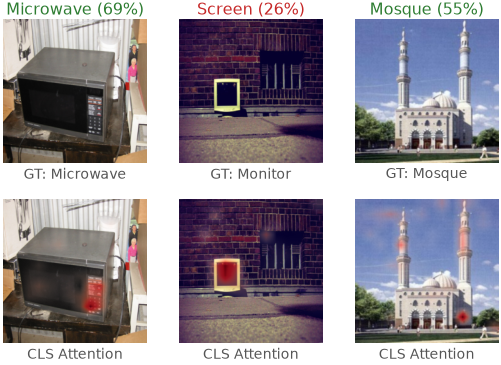

In [50]:
fig, axes = visualize_model(
    model,
    process_fn,
    samples + samples,
    SHORT_CLASS_NAMES,
    run_inference,
    figsize=(3.5, 2.7),
    ncols=len(samples),
)

for i, (image, label) in enumerate(samples, start=1):
    pixel_values, cls_attentions = extract_attention_mask(image)
    
    ax = axes[2+i]
    ax.texts[0].set_text("CLS Attention")
    overlay(pixel_values[0].cpu(), cls_attentions.cpu(), processor, ax, title="")

plt.savefig(os.path.join(BASE_PLOTS, "attention_visualization.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# 4. Patch-Masking Experiment

In [187]:
def masked_run_inference(model, image, mask_fn, mask_ratio):
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)
    inputs.pixel_values = mask_fn(inputs.pixel_values, mask_ratio=mask_ratio)
    with torch.no_grad():
        outputs = model(pixel_values=inputs.pixel_values)
    predicted_label = outputs.logits.argmax(-1).item()
    confidence = outputs.logits.softmax(-1).max(-1).values.item()
    return inputs.pixel_values[0], predicted_label, confidence

In [188]:
def extract_masked_inputs(images, labels, mask_fn, mask_ratios):
    masked_inputs = []
    for mask_ratio in mask_ratios:
        inputs = [
            processor(image, return_tensors="pt").to(DEVICE)
            for image in images
        ]
        inputs = [
            (mask_fn(inp.pixel_values, mask_ratio=mask_ratio), label)
            for inp, label in zip(inputs, labels)
        ]
        masked_inputs.extend(inputs)
    return masked_inputs

def run_inference_from_inputs(model, inputs):
    with torch.inference_mode():
        outputs = model(pixel_values=inputs)
    predicted_label = outputs.logits.argmax(-1).item()
    confidence = outputs.logits.softmax(-1).max(-1).values.item()
    return inputs[0], predicted_label, confidence

In [189]:
images = [sample[0] for sample in samples]
labels = [sample[1] for sample in samples]

randomly_masked_samples = extract_masked_inputs(
    images,
    labels,
    randomly_mask,
    mask_ratios=MASK_RATIOS
)

structurally_masked_samples = extract_masked_inputs(
    images,
    labels,
    structurally_mask,
    mask_ratios=MASK_RATIOS
)

In [190]:
# rearrange so we have all img1 followed by all img2 etc

rearranged_randomly_masked_samples = [None]*len(randomly_masked_samples)
rearranged_structurally_masked_samples = [None]*len(structurally_masked_samples)
for i in range(len(MASK_RATIOS)):
    for j in range(len(samples)):
        new = i + len(MASK_RATIOS)*j  # goes 0, 4, 8, 1, 5, 9, ...
        orig = len(samples)*i + j     # goes 0, 1, 2, 3, 4, 5, 6, 7, 8
        
        rearranged_randomly_masked_samples[new] = randomly_masked_samples[orig]
        rearranged_structurally_masked_samples[new] = structurally_masked_samples[orig]


both_samples = []
for i in range(len(samples)):
    # append all randomly masked first
    for j in range(len(MASK_RATIOS)):
        orig = len(MASK_RATIOS)*i + j
        both_samples.append(rearranged_randomly_masked_samples[orig])

    # append all structurally masked right after randomly masked to make 1 complete row
    for j in range(len(MASK_RATIOS)):
        if MASK_RATIOS[j] == 0.0:
            # random masking already has 0% masked sample
            continue

        orig = len(MASK_RATIOS)*i + j
        both_samples.append(rearranged_structurally_masked_samples[orig])

  0%|          | 0/21 [00:00<?, ?it/s]

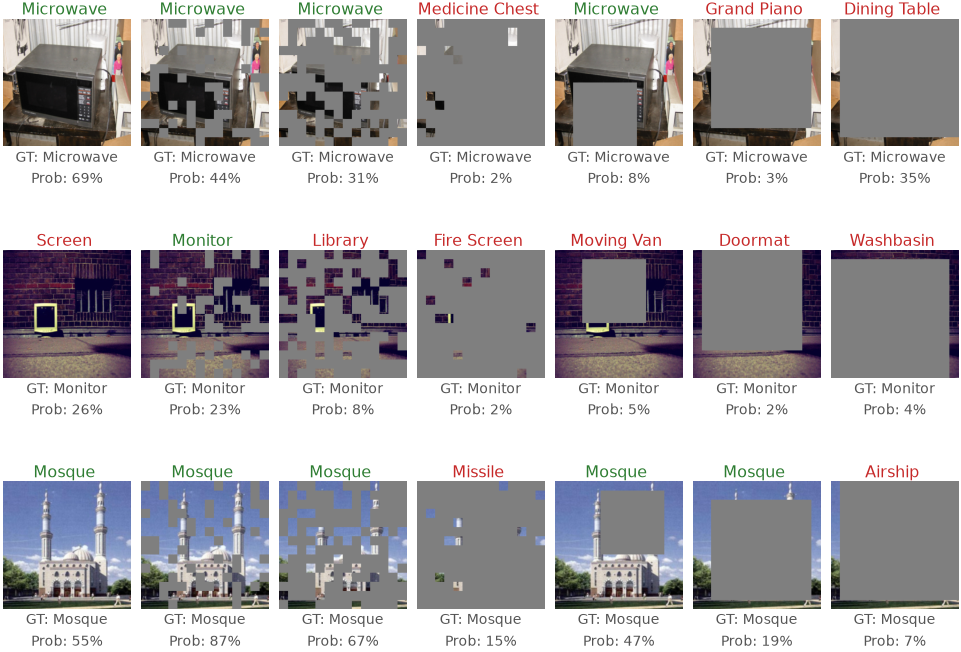

In [208]:
fig, axes = visualize_model(
    model,
    process_fn,
    both_samples,
    SHORT_CLASS_NAMES,
    run_inference_from_inputs,
    title=None,
    ncols=7,
    figsize=(6.5, 5.4),
)

for ax in axes:
    prediction, confidence = ax.title.get_text().split("(")
    confidence = confidence.replace(")", "")

    ax.set_title(
        prediction,
        fontsize=7.5,
        fontweight="normal",
        pad=2,
    )
    ax.text(
        0.5,
        -0.2,
        f"Prob: {confidence}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=6.5,
        color="#555555",
    )

fig.savefig(os.path.join(BASE_PLOTS, f"model_visualization_with_masks.pdf"), bbox_inches="tight", dpi=300)
plt.show()

  0%|          | 0/21 [00:00<?, ?it/s]

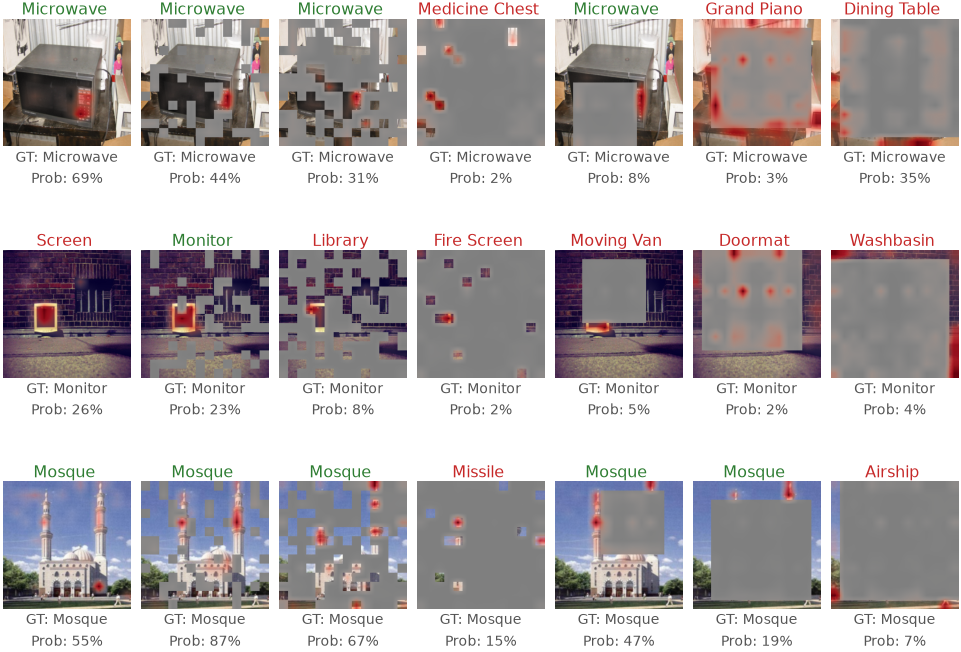

In [210]:
fig, axes = visualize_model(
    model,
    process_fn,
    both_samples,
    SHORT_CLASS_NAMES,
    run_inference_from_inputs,
    title=None,
    ncols=7,
    figsize=(6.5, 5.4),
)

for i, (inputs, label) in enumerate(both_samples):
    pixel_values, cls_attentions = extract_attention_mask_from_inputs(inputs)
    
    ax = axes[i]
    prediction, confidence = ax.title.get_text().split("(")
    confidence = confidence.replace(")", "")

    ax.set_title(
        prediction,
        fontsize=7.5,
        fontweight="normal",
        pad=2,
    )
    ax.text(
        0.5,
        -0.2,
        f"Prob: {confidence}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=6.5,
        color="#555555",
    )


    overlay(pixel_values[0].cpu(), cls_attentions.cpu(), processor, ax)

fig.savefig(os.path.join(BASE_PLOTS, f"attention_visualization_with_masks.pdf"), bbox_inches="tight", dpi=300)
plt.show()

In [6]:
class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

def load_imagenet_val(batch_size, n_images=1000):
    ds = load_dataset(
        "ILSVRC/imagenet-1k",
        split="validation",
        streaming=True,
        token=os.environ["HF_TOKEN"],
    ).take(n_images)

    images, labels = [], []
    for x in tqdm(ds, total=n_images, desc="Loading ImageNet"):
        images.append(x["image"].convert("RGB"))
        labels.append(x["label"])

    def collate_fn(batch):
        return {
            "image": [x[0] for x in batch],
            "labels": torch.tensor([x[1] for x in batch]),
        }

    return DataLoader(
        SimpleDataset(images, labels),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
    )

@torch.inference_mode()
def compute_imagenet_top1_accuracy(
    model,
    processor,
    dataloader,
    mask_fn,
    total_iterations=None,
):
    model.eval()

    correct, total = 0, 0
    for batch in tqdm(dataloader, total=total_iterations, desc="Running inference..."):
        inputs = processor(images=batch["image"], return_tensors="pt")
        pixel_values = inputs.pixel_values

        pixel_values = mask_fn(pixel_values, mask_ratio=0.5).to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)

        outputs = model(pixel_values=pixel_values)

        correct += (outputs.logits.argmax(dim=1) == labels).sum().item()
        total += labels.numel()

    return correct / total

In [7]:
N_IMAGES = 1000
BATCH_SIZE = 8
total_iterations = (N_IMAGES + BATCH_SIZE - 1) // BATCH_SIZE

In [8]:
dataloader = load_imagenet_val(batch_size=BATCH_SIZE, n_images=N_IMAGES)

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Loading ImageNet:   0%|          | 0/1000 [00:00<?, ?it/s]

'timed out' thrown while requesting GET https://huggingface.co/datasets/ILSVRC/imagenet-1k/resolve/49e2ee26f3810fb5a7536bbf732a7b07389a47b5/data/validation-00000-of-00014.parquet
Retrying in 1s [Retry 1/5].
'[Errno 101] Network is unreachable' thrown while requesting GET https://huggingface.co/datasets/ILSVRC/imagenet-1k/resolve/49e2ee26f3810fb5a7536bbf732a7b07389a47b5/data/validation-00000-of-00014.parquet
Retrying in 1s [Retry 1/5].


In [9]:
random_acc = compute_imagenet_top1_accuracy(model, processor, dataloader, randomly_mask, total_iterations=total_iterations)
print(f"Random-mask Top-1 accuracy: {random_acc:.4f}")

Running inference...:   0%|          | 0/125 [00:00<?, ?it/s]

Random-mask Top-1 accuracy: 0.5610


In [10]:
structure_acc = compute_imagenet_top1_accuracy(model, processor, dataloader, structurally_mask, total_iterations=total_iterations)
print(f"Structurally-mask Top-1 accuracy: {structure_acc:.4f}")

Running inference...:   0%|          | 0/125 [00:00<?, ?it/s]

Structurally-mask Top-1 accuracy: 0.4330


In [11]:
with open(os.path.join(BASE, "imagenet-top1.json"), "w") as f:
    f.write(json.dumps({
        "random_acc": random_acc,
        "structure_acc": structure_acc,
    }))

In [3]:
with open(os.path.join(BASE, "imagenet-top1.json"), "r") as f:
    accs = json.loads(f.read())
    random_acc = accs["random_acc"]
    structure_acc = accs["structure_acc"]

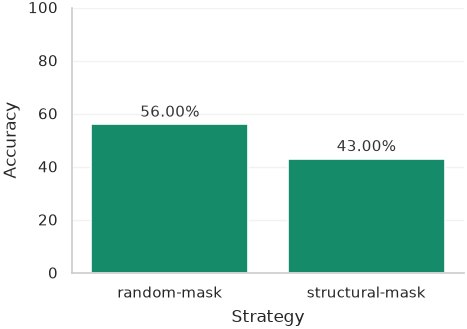

In [7]:
color = sns.color_palette("colorblind")[2]
fig,ax = plot_bar(
    list(map(lambda x: int(x*100), [random_acc, structure_acc])),
    ["random-mask", "structural-mask"],
    title=None,
    xlabel="Strategy",
    ylabel="Accuracy", fmt="%.2f%%",
    figsize=(3.25, 2.4),
    color=color,
)
ax.set_ylim(0,100)

plt.savefig(os.path.join(BASE_PLOTS, "masking_strategy_comparison.pdf"), bbox_inches="tight", dpi=300)
plt.show()